# Deploying a Model as an Endpoint 

### What is an Endpoint? 🤔

Azureml allows you to deploy models as endpoints. This means that you can send data to the endpoint and get a prediction back. In order to do this, you need to create a scoring script that will be used to make predictions, and an endpoint configuration that will define the compute resources that will be used to serve the endpoint. 

We will be making use of the `KubernetesOnlineEndpoint` class to deploy the model as an endpoint. This class will deploy the model to the already running K8s cluster. The class will also create a service that will expose the model as an endpoint. We use this instead of the `ManagedOnlineEndpoint` class because the `ManagedOnlineEndpoint` class will create Azure compute instances to serve the endpoint, which is more expensive and less performant than using the already running K8s cluster. 

### Local Deployment 🏠

We will begin by deploying the model locally. This is useful for testing the endpoint before deploying it to the cloud. It is also useful for debugging the endpoint, and for testing the endpoint with a small amount of data. It will make the deployment process faster and easier.

First, we will create the endpoint configuration. This will define the compute resources that will be used to serve the endpoint.

**_Note: The local deployment will only work if you have Docker installed on your machine, and the Docker daemon is running._**

- Import the necessary libraries and modules.

In [3]:
# import required libraries
from azure.ai.ml import MLClient

from azure.ai.ml.entities import (
    KubernetesOnlineEndpoint,
    KubernetesOnlineDeployment,
    Model,
    Environment,
    CodeConfiguration,
)
from azure.identity import DefaultAzureCredential, ClientSecretCredential
from azure.ai.ml.entities._deployment.resource_requirements_settings import (
    ResourceRequirementsSettings,
)
from azure.ai.ml.entities._deployment.container_resource_settings import (
    ResourceSettings,
)

- Connect to the MLClient 

In [ ]:
subscription_id = 
resource_group = 
workspace_name = 
tenant_id = 
client_id = 
client_secret = 

credential = ClientSecretCredential(tenant_id, client_id, client_secret)
# get a handle to the workspace
ml_client = MLClient(
    credential, subscription_id, resource_group, workspace_name
)

Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


- Create the endpoint configuration for the local deployment 

In [3]:
# Creating a local endpoint
import datetime

local_endpoint_name = "local-" + datetime.datetime.now().strftime("%m%d%H%M%f")

# create an online endpoint
endpoint = KubernetesOnlineEndpoint(
    name=local_endpoint_name, description="this is a sample local endpoint"
)

In [4]:
print(f"Creating local endpoint: {local_endpoint_name}")

Creating local endpoint: local-06211248343768


- Install the docker package

In [5]:
# Install docker package in the current Jupyter kernel
#import sys

#!{sys.executable} -m pip install docker

- Create a local endpoint, using the `local` deployment target. This will create a local endpoint that will run on your machine using Docker.

In [6]:
ml_client.online_endpoints.begin_create_or_update(endpoint, local=True)

Creating local endpoint (local-06211248343768) .Done (0m 5s)


ManagedOnlineEndpoint({'public_network_access': None, 'provisioning_state': None, 'scoring_uri': None, 'openapi_uri': None, 'name': 'local-06211248343768', 'description': 'this is a sample local endpoint', 'tags': {}, 'properties': {}, 'print_as_yaml': False, 'id': None, 'Resource__source_path': '', 'base_path': WindowsPath('C:/Users/emilp/.azureml/inferencing/local-06211248343768'), 'creation_context': None, 'serialize': <msrest.serialization.Serializer object at 0x000001DEA24F23C0>, 'auth_mode': 'key', 'location': None, 'identity': None, 'traffic': {}, 'mirror_traffic': {}, 'kind': None})

- Now create the deployment config for the local endpoint. This will be used to create a service that will expose the model as an endpoint. You need to specfiy the model, the environment, the scoring script, and the endpoint configuration. The model needs to be a local model for this to work locally.

**_Note: The environment and the scoring script are the main sources of error at this stage. You will need to make sure the environment has all the pre-requisites and that all of your path definitions for scoring are correct. Extensive logging is recommended for debugging._**

In [16]:
from azure.ai.ml.entities import Environment
import os

model = Model(path=r"C:\Users\emilp\Documents\GitHub\2024-25d-fai2-adsai-group-cv9\AzureML\INPUT_model")
env = Environment(
    conda_file=r"C:\Users\emilp\Documents\GitHub\2024-25d-fai2-adsai-group-cv9\AzureML\environment.yml",
    image="mcr.microsoft.com/azureml/curated/tensorflow-2.16-cuda11:4"#"deanis/azure-gpu-inference"#"tensorflow/tensorflow:latest-gpu"#"mcr.microsoft.com/azureml/curated/tensorflow-2.16-cuda11:4"#"mcr.microsoft.com/azureml/openmpi4.1.0-ubuntu20.04",
)


green_deployment = KubernetesOnlineDeployment(
    name="green",
    endpoint_name="local-0621124834376",
    model=model,
    environment=env,
    code_configuration=CodeConfiguration(
        code=r"C:\Users\emilp\Documents\GitHub\2024-25d-fai2-adsai-group-cv9\AxonRooter\src\axonrooter", scoring_script="scoring.py"
    ),
    instance_count=1,
    resources=ResourceRequirementsSettings(
        requests=ResourceSettings(
            cpu="100m",
            memory="0.5Gi",
            gpu="1",
        ),
    ),
)

- Next, deploy the model as an endpoint, using the `local` flag. This will deploy the model to the local endpoint that was created earlier.

In [17]:
ml_client.online_deployments.begin_create_or_update(
    deployment=green_deployment, local=True
)

Invalid type NoneType for attribute 'resource_group_name' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types
Creating local deployment (local-0621124834376 / green) .
Building Docker image from Dockerfile
Step 1/6 : FROM mcr.microsoft.com/azureml/curated/tensorflow-2.16-cuda11:4
 ---> ea8917b9204a
Step 2/6 : RUN mkdir -p /var/azureml-app/
 ---> Using cache
 ---> 1e8472734a2d
Step 3/6 : WORKDIR /var/azureml-app/
 ---> Using cache
 ---> b8cce05d3526
Step 4/6 : COPY conda.yml /var/azureml-app/
 ---> Using cache
 ---> b0637650d77a
Step 5/6 : RUN conda env create -n inf-conda-env --file conda.yml
 ---> Using cache
 ---> 96e92ac307c2
Step 6/6 : CMD ["conda", "run", "--no-capture-output", "-n", "inf-conda-env", "runsvdir", "/var/runit"]
 ---> Using cache
 ---> 74a5d2bfe3af
Successfully built 74a5d2bfe3af
Successfully tagged local-0621124834376:green

Starting up endpoint...Done (0m 20s)
Invalid type NoneType for attribute 'resource_group_name' value. 

KubernetesOnlineDeployment({'provisioning_state': 'Succeeded', 'endpoint_name': 'local-0621124834376', 'type': 'Kubernetes', 'name': 'green', 'description': None, 'tags': {}, 'properties': {}, 'print_as_yaml': False, 'id': None, 'Resource__source_path': '', 'base_path': WindowsPath('c:/Users/emilp/Downloads'), 'creation_context': None, 'serialize': <msrest.serialization.Serializer object at 0x000001FBC21ECFB0>, 'model': Model({'job_name': None, 'intellectual_property': None, 'system_metadata': None, 'is_anonymous': False, 'auto_increment_version': False, 'auto_delete_setting': None, 'name': 'b9c696e9eef745910c2400c64c123633', 'description': None, 'tags': {}, 'properties': {}, 'print_as_yaml': False, 'id': None, 'Resource__source_path': '', 'base_path': WindowsPath('c:/Users/emilp/Downloads'), 'creation_context': None, 'serialize': <msrest.serialization.Serializer object at 0x000001FBC12C7170>, 'version': '1', 'latest_version': None, 'path': 'C:\\Users\\emilp\\Documents\\GitHub\\2024-25

- You can check the status of the deployment by looking at the logs of the docker container that was created. In docker desktop, you can do this by clicking on the container, and then clicking on the logs tab. The container will be named something like `local-06160804621045.blue`.

- You can also check the status of the deployment by looking at the logs of the deployment with the `ml_client`. You can do this by calling the `get_logs` method on the deployment object.

In [19]:
status = ml_client.online_endpoints.get(name="local-0621124834376", local=True)
print(status)

Invalid type NoneType for attribute 'resource_group_name' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types
Invalid type NoneType for attribute 'resource_group_name' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


auth_mode: key
location: local
mirror_traffic: {}
name: local-0621124834376
properties: {}
provisioning_state: Succeeded
scoring_uri: http://localhost:32768/score
tags: {}
traffic: {}



In [10]:
logs = ml_client.online_deployments.get_logs(
    name="blue", endpoint_name=local_endpoint_name, local=True, lines=500
)

print(logs)


== CUDA ==

CUDA Version 11.8.0

Container image Copyright (c) 2016-2023, NVIDIA CORPORATION & AFFILIATES. All rights reserved.

This container image and its contents are governed by the NVIDIA Deep Learning Container License.
By pulling and using the container, you accept the terms and conditions of this license:
https://developer.nvidia.com/ngc/nvidia-deep-learning-container-license

A copy of this license is made available in this container at /NGC-DL-CONTAINER-LICENSE for your convenience.

   Use the NVIDIA Container Toolkit to start this container with GPU support; see
   https://docs.nvidia.com/datacenter/cloud-native/ .

2025-06-21T10:48:10,536017359+00:00 - rsyslog/run 
2025-06-21T10:48:10,541861960+00:00 - nginx/run 
2025-06-21T10:48:10,543748694+00:00 - gunicorn/run 
2025-06-21T10:48:10,547958779+00:00 | gunicorn/run | 
2025-06-21T10:48:10,551693578+00:00 | gunicorn/run | ###############################################
2025-06-21T10:48:10,555657480+00:00 | gunicorn/run | Az

### Local Testing 🧪

- If the deployment is successful, you can test the endpoint by sending data to it. We will do this by sending a request to the endpoint using the `invoke` method on the deployment object. This will send a request to the endpoint, and return the response. The format of the request and response will depend on the scoring script that was used to create the endpoint. In this case the scoring script is `scoring.py`, which expects a JSON object with a key `data` that contains the data to be scored. The data is a base64 encoded image.

In [11]:
import base64
import json
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential

# === Step 1: Encode image to base64 JSON ===
image_path = r"C:\Users\emilp\Documents\Buas_Y2\Block_B\data_sets\Y-Combined_dataset\images\train_Elavendan_232345_im3.png"
json_path = "sample-request4.json"

with open(image_path, "rb") as img:
    encoded = base64.b64encode(img.read()).decode("utf-8")

with open(json_path, "w") as f:
    json.dump({"data": encoded}, f)

print(f"[INFO] Request written to {json_path}")

# === Step 2: Invoke local endpoint ===
from azure.ai.ml import MLClient

# Setup MLClient (use your config if needed)
#ml_client = MLClient.from_config()  # Assumes you have a local .azureml/config.json

# Invoke endpoint and print result
response = ml_client.online_endpoints.invoke(
    endpoint_name=local_endpoint_name,  # Replace with your actual endpoint name
    request_file=json_path,
    local=True
)

print("[RESULT] Prediction from endpoint:")
print(response)


[INFO] Request written to sample-request4.json
[RESULT] Prediction from endpoint:
"{\"predicted_mask_base64\": \"...\"}"


Invalid type NoneType for attribute 'resource_group_name' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


[INFO] Request written to sample-request4.json


Invalid type NoneType for attribute 'resource_group_name' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


[RESULT] Raw response received.
[RESULT] Raw response received:
'"{\\"predicted_mask_base64\\": \\"...\\"}"'
[INFO] Decoding predicted mask from base64...


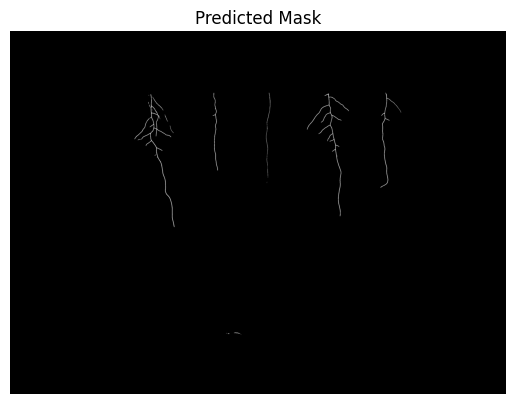

[INFO] Saved predicted mask to predicted_mask.png


In [21]:
import base64
import json
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential
from PIL import Image
import io
import matplotlib.pyplot as plt

# === Step 1: Encode image to base64 JSON ===
image_path = r"C:\Users\emilp\Documents\Buas_Y2\Block_B\data_sets\Y-Combined_dataset\images\train_Elavendan_232345_im3.png"
json_path = "sample-request4.json"

with open(image_path, "rb") as img:
    encoded = base64.b64encode(img.read()).decode("utf-8")

with open(json_path, "w") as f:
    json.dump({"data": encoded}, f)

print(f"[INFO] Request written to {json_path}")

# === Step 2: Invoke local endpoint ===
# Make sure ml_client is defined
#ml_client = MLClient.from_config(credential=DefaultAzureCredential())

response = ml_client.online_endpoints.invoke(
    endpoint_name="local-0621124834376",  # <-- your actual endpoint name
    request_file=json_path,
    local=True
)

print("[RESULT] Raw response received.")

# === Step 3: Decode and save the predicted mask ===
# === Step 3: Decode and save the predicted mask ===
print("[RESULT] Raw response received:")
print(repr(response))  # Helps debug what's really returned

# === Decode double-encoded response ===
try:
    response_dict = json.loads(json.loads(response))  # Double decode needed

    if "predicted_mask_base64" in response_dict:
        print("[INFO] Decoding predicted mask from base64...")
        mask_data = base64.b64decode(response_dict["predicted_mask_base64"])
        mask_image = Image.open(io.BytesIO(mask_data))

        # Save and show the image
        output_path = "predicted_mask.png"
        mask_image.save(output_path)

        plt.imshow(mask_image, cmap="gray")
        plt.title("Predicted Mask")
        plt.axis("off")
        plt.show()

        print(f"[INFO] Saved predicted mask to {output_path}")

    else:
        print(f"[ERROR] {response_dict.get('error', 'No mask found in response')}")

except Exception as e:
    print(f"[ERROR] Could not decode or visualize mask: {e}")
    print(f"[DEBUG] Raw response: {repr(response)}")




# Cloud Deployment 🌐

Once the local deployment is successful, we can deploy the model to the cloud. This is useful for serving the model to a large number of users, and for making the model accessible from anywhere. It is also useful for deploying the model to a production environment.

- First we need to create the endpoint configuration for the cloud deployment. This will define thename, authorisation method, and compute resources that will be used to serve the endpoint. We will use the `KubernetesOnlineEndpoint` class to deploy the model to the already running K8s cluster. This class will create a service that will expose the model as an endpoint. We use this instead of the `ManagedOnlineEndpoint` class because the `ManagedOnlineEndpoint` class will create Azure compute instances to serve the endpoint, which is more expensive and less performant than using the already running K8s cluster.

In [4]:
# Creating a unique endpoint name with current datetime to avoid conflicts
import datetime

online_endpoint_name = "cv9-endpoint-" + datetime.datetime.now().strftime("%m%d%H%M%f")

# create an online endpoint
endpoint = KubernetesOnlineEndpoint(
    name=online_endpoint_name,
    compute="adsai-lambda-0",
    description="this is a sample online endpoint",
    auth_mode="key",
    tags={"Type": "Review Session"},
)

In [5]:
ml_client.begin_create_or_update(endpoint).result()

KubernetesOnlineEndpoint({'provisioning_state': 'Succeeded', 'scoring_uri': 'http://194.171.191.227:30526/api/v1/endpoint/cv9-endpoint-06211358581782/score', 'openapi_uri': 'http://194.171.191.227:30526/api/v1/endpoint/cv9-endpoint-06211358581782/swagger.json', 'name': 'cv9-endpoint-06211358581782', 'description': 'this is a sample online endpoint', 'tags': {'Type': 'Review Session'}, 'properties': {'createdBy': 'a2230f31-0fda-428d-8c5c-ec79e91a49f5', 'createdAt': '2025-06-21T11:58:15.754679+0000', 'lastModifiedAt': '2025-06-21T11:58:15.754679+0000', 'azureml.onlineendpointid': '/subscriptions/0a94de80-6d3b-49f2-b3e9-ec5818862801/resourcegroups/buas-y2/providers/microsoft.machinelearningservices/workspaces/cv9-2025/onlineendpoints/cv9-endpoint-06211358581782', 'AzureAsyncOperationUri': 'https://management.azure.com/subscriptions/0a94de80-6d3b-49f2-b3e9-ec5818862801/providers/Microsoft.MachineLearningServices/locations/westeurope/mfeOperationsStatus/oeidp:33feec40-8666-4677-9aa3-693e679

- Next we need to create the deployment config for the cloud deployment. This will be used to create a service that will expose the model as an endpoint. You need to specfiy the model, the environment, the scoring script, and the endpoint configuration. We can now use registered models (and environments) for this deployment.

## Blue deployement

In [6]:
from azure.ai.ml.entities import Environment
from azure.ai.ml.entities import CodeConfiguration, KubernetesOnlineDeployment, ResourceSettings, ResourceRequirementsSettings

registered_model_name = "axonrooter-finetuned"
latest_model_version = 8
registered_environment_name = "my-custom-env-2"
latest_environment_version = "1.11"  # Use string version just to be safe

# Use registered environment (your custom env with patchify, etc.)
env = ml_client.environments.get(name=registered_environment_name, version=latest_environment_version)

model = ml_client.models.get(name=registered_model_name, version=latest_model_version)

blue_deployment = KubernetesOnlineDeployment(
    name="blue",
    endpoint_name=online_endpoint_name,
    model=model,
    environment=env,  # Use your registered env here
    code_configuration=CodeConfiguration(
        code=r"C:\Users\emilp\Documents\GitHub\2024-25d-fai2-adsai-group-cv9\AxonRooter\src\axonrooter",
        scoring_script="scoring.py"
    ),
    instance_count=1,
    resources=ResourceRequirementsSettings(
        requests=ResourceSettings(cpu="100m", memory="0.5Gi"),
    ),
)

ml_client.begin_create_or_update(blue_deployment).result()


Check: endpoint cv9-endpoint-06211358581782 exists


...............................................................

KubernetesOnlineDeployment({'provisioning_state': 'Succeeded', 'endpoint_name': 'cv9-endpoint-06211358581782', 'type': 'Kubernetes', 'name': 'blue', 'description': None, 'tags': {'ModelId': 'axonrooter-finetuned:8'}, 'properties': {'AzureAsyncOperationUri': 'https://management.azure.com/subscriptions/0a94de80-6d3b-49f2-b3e9-ec5818862801/providers/Microsoft.MachineLearningServices/locations/westeurope/mfeOperationsStatus/odidp:33feec40-8666-4677-9aa3-693e6795d6c9:13cea948-1a52-4532-a5a4-8f4eb686c3a8?api-version=2023-04-01-preview'}, 'print_as_yaml': False, 'id': '/subscriptions/0a94de80-6d3b-49f2-b3e9-ec5818862801/resourceGroups/buas-y2/providers/Microsoft.MachineLearningServices/workspaces/CV9-2025/onlineEndpoints/cv9-endpoint-06211358581782/deployments/blue', 'Resource__source_path': '', 'base_path': 'c:\\Users\\emilp\\Downloads', 'creation_context': None, 'serialize': <msrest.serialization.Serializer object at 0x000002128F577140>, 'model': '/subscriptions/0a94de80-6d3b-49f2-b3e9-ec58

- We can now deploy the model as an endpoint, **without** the `local` flag. This will deploy the model to the cloud endpoint that was created earlier.

In [26]:
ml_client.begin_create_or_update(blue_deployment).result()

Check: endpoint cv9-endpoint-06211323363453 exists


Uploading axonrooter (23.71 MBs): 100%|##########| 23709125/23709125 [00:06<00:00, 3763547.33it/s]




.........................................................................................................................................

HttpResponseError: (KubernetesOperationError) Operation failed in Kubernetes cluster. Reason:UserScriptImportError Details:Errors Occurred in User Script when importing modules, please check the deployment logs for more details. Please see troubleshooting guide, available here: https://aka.ms/amlarc-tsg
Code: KubernetesOperationError
Message: Operation failed in Kubernetes cluster. Reason:UserScriptImportError Details:Errors Occurred in User Script when importing modules, please check the deployment logs for more details. Please see troubleshooting guide, available here: https://aka.ms/amlarc-tsg

- The last step is to route traffic to the deploymennt. We only have 1 deployment (blue), so we can route all traffic to it. We can do this by calling the `endpoint.traffic` method on the endpoint object, and passing in the percentage of traffic that should be routed to the deployment. In this case we will route 100% of the traffic to the deployment.

In [7]:
# blue deployment takes 100 traffic
endpoint.traffic = {"blue": 100}
ml_client.begin_create_or_update(endpoint).result()

KubernetesOnlineEndpoint({'provisioning_state': 'Succeeded', 'scoring_uri': 'http://194.171.191.227:30526/api/v1/endpoint/cv9-endpoint-06211358581782/score', 'openapi_uri': 'http://194.171.191.227:30526/api/v1/endpoint/cv9-endpoint-06211358581782/swagger.json', 'name': 'cv9-endpoint-06211358581782', 'description': 'this is a sample online endpoint', 'tags': {'Type': 'Review Session'}, 'properties': {'createdBy': 'a2230f31-0fda-428d-8c5c-ec79e91a49f5', 'createdAt': '2025-06-21T11:58:15.754679+0000', 'lastModifiedAt': '2025-06-21T12:06:47.187435+0000', 'azureml.onlineendpointid': '/subscriptions/0a94de80-6d3b-49f2-b3e9-ec5818862801/resourcegroups/buas-y2/providers/microsoft.machinelearningservices/workspaces/cv9-2025/onlineendpoints/cv9-endpoint-06211358581782', 'AzureAsyncOperationUri': 'https://management.azure.com/subscriptions/0a94de80-6d3b-49f2-b3e9-ec5818862801/providers/Microsoft.MachineLearningServices/locations/westeurope/mfeOperationsStatus/oeidp:33feec40-8666-4677-9aa3-693e679

- You can check the status of the deployment by looking at the logs of the deployment with the `ml_client`. You can do this by calling the `get_logs` method on the deployment object.

In [5]:
from azure.ai.ml import MLClient
from azure.ai.ml.entities import (
    KubernetesOnlineDeployment,
    CodeConfiguration,
    ResourceSettings,
    ResourceRequirementsSettings,
    Environment,
)
from azure.identity import DefaultAzureCredential

# Get the latest model version
model_name = "axonrooter-finetuned"
model_versions = ml_client.models.list(name=model_name)
latest_model = max(model_versions, key=lambda m: int(m.version))


Invalid type NoneType for attribute 'resource_group_name' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types
Invalid type NoneType for attribute 'resource_group_name' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


In [11]:
green_deployment = KubernetesOnlineDeployment(
    name="green",  # deployment name
    endpoint_name="cv9-endpoint-06211358581782",  # string!
    model=latest_model,
    environment=Environment(
        image="mcr.microsoft.com/azureml/curated/tensorflow-2.16-cuda11:4"
    ),
    code_configuration=CodeConfiguration(
        code=r"C:\Users\emilp\Documents\GitHub\2024-25d-fai2-adsai-group-cv9\AxonRooter\src\axonrooter",
        scoring_script="scoring.py"
    ),
    instance_count=1,
    resources=ResourceRequirementsSettings(
        requests=ResourceSettings(
            cpu="100m",
            memory="0.5Gi",
        ),
    ),
)


In [8]:
status = ml_client.online_endpoints.get(name=online_endpoint_name)

print(status)

auth_mode: key
compute: azureml:/subscriptions/0a94de80-6d3b-49f2-b3e9-ec5818862801/resourceGroups/buas-y2/providers/Microsoft.MachineLearningServices/workspaces/CV9-2025/computes/adsai-lambda-0
description: this is a sample online endpoint
id: /subscriptions/0a94de80-6d3b-49f2-b3e9-ec5818862801/resourceGroups/buas-y2/providers/Microsoft.MachineLearningServices/workspaces/CV9-2025/onlineEndpoints/cv9-endpoint-06211358581782
identity:
  principal_id: 31925297-8afc-4492-b96f-b40bc4349791
  tenant_id: 0a33589b-0036-4fe8-a829-3ed0926af886
  type: system_assigned
kind: K8S
location: westeurope
mirror_traffic: {}
name: cv9-endpoint-06211358581782
openapi_uri: http://194.171.191.227:30526/api/v1/endpoint/cv9-endpoint-06211358581782/swagger.json
properties:
  AzureAsyncOperationUri: https://management.azure.com/subscriptions/0a94de80-6d3b-49f2-b3e9-ec5818862801/providers/Microsoft.MachineLearningServices/locations/westeurope/mfeOperationsStatus/oeidp:33feec40-8666-4677-9aa3-693e6795d6c9:84db08

In [9]:
logs = ml_client.online_deployments.get_logs(
    name="blue", endpoint_name=online_endpoint_name, lines=50
)

print(logs)

2025-06-21 11:57:59,277 I [327] gunicorn.access - 127.0.0.1 - - [21/Jun/2025:11:57:59 +0000] "GET / HTTP/1.0" 200 7 "-" "kube-probe/1.32"
2025-06-21 11:58:00,445 I [327] gunicorn.access - 127.0.0.1 - - [21/Jun/2025:11:58:00 +0000] "GET / HTTP/1.0" 200 7 "-" "kube-probe/1.32"
2025-06-21 11:58:09,264 I [327] gunicorn.access - 127.0.0.1 - - [21/Jun/2025:11:58:09 +0000] "GET / HTTP/1.0" 200 7 "-" "kube-probe/1.32"
2025-06-21 11:58:10,445 I [327] gunicorn.access - 127.0.0.1 - - [21/Jun/2025:11:58:10 +0000] "GET / HTTP/1.0" 200 7 "-" "kube-probe/1.32"
2025-06-21 11:58:19,264 I [327] gunicorn.access - 127.0.0.1 - - [21/Jun/2025:11:58:19 +0000] "GET / HTTP/1.0" 200 7 "-" "kube-probe/1.32"
2025-06-21 11:58:20,444 I [327] gunicorn.access - 127.0.0.1 - - [21/Jun/2025:11:58:20 +0000] "GET / HTTP/1.0" 200 7 "-" "kube-probe/1.32"
2025-06-21 11:58:26,344 I [327] gunicorn.access - 127.0.0.1 - - [21/Jun/2025:11:58:26 +0000] "OPTIONS / HTTP/1.0" 200 0 "-" "Go-http-client/1.1"
2025-06-21 11:58:26,348 I [

In [10]:
# Get the details for online endpoint
endpoint = ml_client.online_endpoints.get(name=online_endpoint_name)

# existing traffic details
print(endpoint.traffic)

# Get the scoring URI
print(endpoint.scoring_uri)

{'blue': 100}
http://194.171.191.227:30526/api/v1/endpoint/cv9-endpoint-06211358581782/score


### Testing the Cloud Endpoint and Blue Deployment🧪

The scoring script for the cloud deployment is the same as the scoring script for the local deployment. It expects a JSON object with a key `data` that contains the data to be scored. The data is a base64 encoded image. 

In [4]:
import base64
import json

image_path = r"C:\Users\emilp\Documents\Buas_Y2\Block_B\data_sets\Y-Combined_dataset\images\train_Elavendan_232345_im3.png"
json_path = "cloud_request.json"

with open(image_path, "rb") as img:
    encoded = base64.b64encode(img.read()).decode("utf-8")

with open(json_path, "w") as f:
    json.dump({"data": encoded}, f)

print(f"[INFO] Request written to {json_path}")


[INFO] Request written to cloud_request.json


If you open the deployment in AzureML studio, you can see the status of the deployment, and the logs of the deployment. You can also see the traffic that is being routed to the deployment. If you click on the `consume` tab, you can see the code that you need to use to send data to the endpoint. You can also see the response that you get back from the endpoint.

In [ ]:
import urllib.request
import json
import os
import ssl

def allowSelfSignedHttps(allowed):
    # bypass the server certificate verification on client side
    if allowed and not os.environ.get('PYTHONHTTPSVERIFY', '') and getattr(ssl, '_create_unverified_context', None):
        ssl._create_default_https_context = ssl._create_unverified_context

allowSelfSignedHttps(True) # this line is needed if you use self-signed certificate in your scoring service.

# Request data goes here
# The example below assumes JSON formatting which may be updated
# depending on the format your endpoint expects.
# More information can be found here:
# https://docs.microsoft.com/azure/machine-learning/how-to-deploy-advanced-entry-script
data = {
    "data": base64_image
}

body = str.encode(json.dumps(data))


url = 

api_key = 
if not api_key:
    raise Exception("A key should be provided to invoke the endpoint")

# The azureml-model-deployment header will force the request to go to a specific deployment.
# Remove this header to have the request observe the endpoint traffic rules
headers = {'Content-Type':'application/json', 'Authorization':('Bearer '+ api_key), 'azureml-model-deployment': 'blue' }

req = urllib.request.Request(url, body, headers)

try:
    response = urllib.request.urlopen(req)

    result = response.read()
    print(result)
except urllib.error.HTTPError as error:
    print("The request failed with status code: " + str(error.code))

    # Print the headers - they include the requert ID and the timestamp, which are useful for debugging the failure
    print(error.info())
    print(error.read().decode("utf8", 'ignore'))

The request failed with status code: 401
Server: nginx/1.18.0 (Ubuntu)
Date: Wed, 19 Jun 2024 11:36:36 GMT
Content-Type: text/plain
Content-Length: 22
Connection: close
x-request-id: 3474fda6-8d69-4ed6-8c0b-ce2a46dfdf1f


key_auth_access_denied


Exception occurred while exporting the data.
Traceback (most recent call last):
  File "C:\Users\deanv\AppData\Roaming\Python\Python310\site-packages\opencensus\ext\azure\trace_exporter\__init__.py", line 228, in emit
    self._transmit_from_storage()
  File "C:\Users\deanv\AppData\Roaming\Python\Python310\site-packages\opencensus\ext\azure\common\transport.py", line 80, in _transmit_from_storage
    for blob in self.storage.gets():
  File "C:\Users\deanv\AppData\Roaming\Python\Python310\site-packages\opencensus\ext\azure\common\storage.py", line 129, in gets
    for name in sorted(os.listdir(self.path)):
FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\deanv\\AppData\\Local\\Temp\\opencensus-python-71b954a8-6b7d-43f5-986c-3d3a6605d803'
Exception occurred while exporting the data.
Traceback (most recent call last):
  File "C:\Users\deanv\AppData\Roaming\Python\Python310\site-packages\opencensus\ext\azure\trace_exporter\__init__.py", line 228, in em

# YOU NEED TO INSTALL RUNIT!!!, or use an azure image

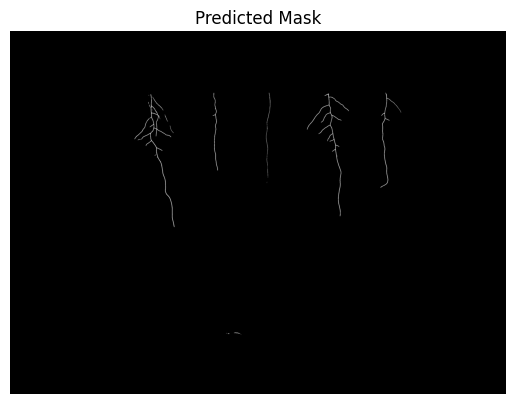

In [27]:
import base64
import io
import json
from PIL import Image
import matplotlib.pyplot as plt

# Manually inserted JSON response (replace with your real base64 string)
response_json = {
    "predicted_mask_base64": "...\\"
}

# Decode the base64 string
mask_base64 = response_json["predicted_mask_base64"]
mask_bytes = base64.b64decode(mask_base64)
mask_image = Image.open(io.BytesIO(mask_bytes))

# Display the image
plt.imshow(mask_image, cmap='gray')
plt.title("Predicted Mask")
plt.axis("off")
plt.show()

# Optionally save
mask_image.save("predicted_mask.png")
